In [1]:
#which version performs better is known as an A/B test.In an A/B test, users are randomly assigned to either the control group (version A) or the experimental group (version B), and their behavior is tracked to see which version yields better results.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
#scipy - a Python library used for scientific and technical computing, which includes functions for statistical analysis, optimization, and more. In this context, we use it to perform the chi-squared test for A/B testing analysis.

In [3]:
events_df = pd.read_csv('../data/raw/events.csv')
events_df['variant'].value_counts()

variant
B    5290
A    5160
Name: count, dtype: int64

In [4]:
purchase_users = events_df[
    events_df['event'] == 'purchase'
]

In [ ]:
purchase_counts = purchase_users.groupby(
    'variant'
)['user_id'].nunique()

print(purchase_counts)

#Looks like B performs better. Now we will perform a chi-squared test to see if the difference is statistically significant.

variant
A    228
B    257
Name: user_id, dtype: int64


In [ ]:

total_users = events_df.groupby(
    'variant'
)['user_id'].nunique()

print(total_users)


variant
A    2457
B    2543
Name: user_id, dtype: int64


In [ ]:
conversion_A = (
    purchase_counts['A'] /
    total_users['A']
) * 100

conversion_B = (
    purchase_counts['B'] /
    total_users['B']
) * 100

print(f"Variant A Conversion: {conversion_A:.2f}%")
print(f"Variant B Conversion: {conversion_B:.2f}%")

Variant A Conversion: 9.28%
Variant B Conversion: 10.11%


In [9]:
#contingency table for chi-squared test - a 2x2 table that summarizes the counts of users who made a purchase and those who did not for each variant. The rows represent the variants (A and B), and the columns represent the outcomes (purchase and no purchase). 

contingency_table = [

    [
        purchase_counts['A'],
        total_users['A'] - purchase_counts['A']
    ],

    [
        purchase_counts['B'],
        total_users['B'] - purchase_counts['B']
    ]
]

print(contingency_table)

[[np.int64(228), np.int64(2229)], [np.int64(257), np.int64(2286)]]


In [14]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("P-value:", p_value)

if p_value < 0.05:

    print(
        "Statistically significant difference detected."
    )

else:

    print(
        "No statistically significant difference detected. The variation may be due to random chance."
    )

#P-value < 0.05 indicates that the difference in conversion rates between variants A and B is statistically significant, suggesting that the observed difference is unlikely to have occurred by random chance and > 0.05 indicates that the difference is not statistically significant, suggesting that the observed difference could have occurred by random chance.

P-value: 0.34748291557626454
No statistically significant difference detected. The variation may be due to random chance.


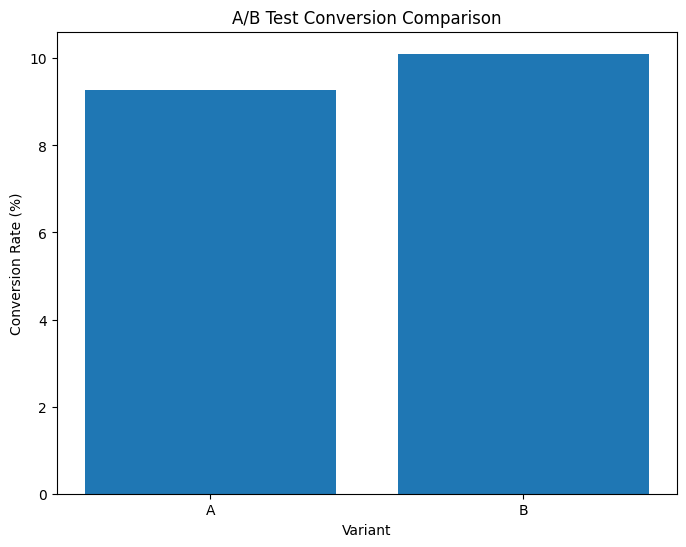

In [13]:
import matplotlib.pyplot as plt

variants = ['A', 'B']

conversion_values = [
    conversion_A,
    conversion_B
]

plt.figure(figsize=(8,6))

plt.bar(
    variants,
    conversion_values
)

plt.title('A/B Test Conversion Comparison')
plt.xlabel('Variant')
plt.ylabel('Conversion Rate (%)')

plt.show()